# Individual Test Run Recon

Analyse the full `transactions` table for a single test execution.

---
## 1. Init

Modify `RESULTS_BASE_DIR` to traverse through subfolders

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

from faultlab.analysis import (
    load_csv,
    enrich_latency_metrics,
    describe_latency_percentiles,
    execution_summary,
    status_summary,
    FAILURE_STATUSES,
    LATENCY_COLS,
    TERMINAL_STATUSES,
    STATUS_COLORS,
)

# == Plotting =====================================================================
sns.set_theme(style="whitegrid")

# == Paths =====================================================================
PROJECT_ROOT_DIR = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT_DIR.joinpath("src")))

RESULTS_BASE_DIR = "results/BASELINE"
# RESULTS_BASE_DIR = "results/GRPC_CONCURRENCY_LIMIT/1"

RESULTS_DIR = PROJECT_ROOT_DIR.joinpath("tests").joinpath(RESULTS_BASE_DIR)

print(f"Project root : {PROJECT_ROOT_DIR}")
print(f"Results dir  : {RESULTS_DIR}")

Project root : /Users/kr1sel/Documents/Code/|_MSC_Proj_|/faultlab
Results dir  : /Users/kr1sel/Documents/Code/|_MSC_Proj_|/faultlab/tests/results/BASELINE


---
### 2. Load File

Set `FILE_NAME` variable

In [2]:
FILE_NAME = "test_baseline_10000_txs_10_accounts_20260531_164522.csv"

CSV_FILE = RESULTS_DIR.joinpath(f"{FILE_NAME}{"" if FILE_NAME.endswith(".csv") else ".csv"}")
assert CSV_FILE and CSV_FILE.exists(), f"File not found: {CSV_FILE}"

In [3]:
df = load_csv(CSV_FILE)

print(f"Loaded {len(df)} rows from {CSV_FILE.name}")
display(df.head(5))

Loaded 10000 rows from test_baseline_10000_txs_10_accounts_20260531_164522.csv


,id,amount_ether,confirmed_at,created_at,error_message,failed_at,from_address,hash,mined_block,nonce,...,signing_started_at,status,submission_block,submission_retries,submitted_at,sweeper_attempts,to_address,trace_id,updated_at,version
0,9c8ccc3f-eff1-49d8-960f-b8caf45a995d,0.63,2026-05-31 14:42:53.869400+00:00,2026-05-31 14:42:29.367173+00:00,NaN,NaT,0x611e27a33629087d55b2d7bd786c27a117a50ab6,0xb1dd71762e6fbabd05b44fa857c09352c836fc6aba6a...,14,19,...,2026-05-31 14:42:37.934139+00:00,CONFIRMED,13,0,2026-05-31 14:42:44.960818+00:00,NaN,0x3801bc8bf13006569c39c5c0b09bfe800ddc534a,9377,2026-05-31 14:42:44.960818+00:00,4
1,2d0a51f0-a038-4941-93dc-a4eba9490f03,0.39,2026-05-31 14:42:53.869400+00:00,2026-05-31 14:42:29.431170+00:00,NaN,NaT,0x611e27a33629087d55b2d7bd786c27a117a50ab6,0x21e925870afeb526746406b6cac6356dcfe3f583af55...,14,20,...,2026-05-31 14:42:35.739702+00:00,CONFIRMED,13,0,2026-05-31 14:42:45.011823+00:00,NaN,0xb3ca2e419c6594cf5c8d78593a5f20f0f1f72ed8,9387,2026-05-31 14:42:45.011823+00:00,4
2,7cf5acb0-b56b-4ec3-8d41-6d08f480aa4d,0.11,2026-05-31 14:44:56.455674+00:00,2026-05-31 14:42:57.140301+00:00,NaN,NaT,0xd5a65d7460ee01be80fec98c147bcf22dfe0067f,0x34e955fd439854f1af9cd8f180b4ab1c493f56a168a8...,39,707,...,2026-05-31 14:43:57.594968+00:00,CONFIRMED,38,0,2026-05-31 14:44:49.324580+00:00,NaN,0xd2bfeb1591a2a839fb1874e270006f472cc1b9d4,2857,2026-05-31 14:44:49.324580+00:00,4
3,135aaf42-5da8-4d00-846b-d9e57b0e5802,0.90,2026-05-31 14:45:06.525300+00:00,2026-05-31 14:43:00.844465+00:00,NaN,NaT,0xb3ca2e419c6594cf5c8d78593a5f20f0f1f72ed8,0x0df086c35b02cec253aed50230e565a0a1e2c53c75c8...,41,822,...,2026-05-31 14:44:09.047941+00:00,CONFIRMED,40,0,2026-05-31 14:44:57.569642+00:00,NaN,0xd5a65d7460ee01be80fec98c147bcf22dfe0067f,7036,2026-05-31 14:44:57.569642+00:00,4
4,376950f4-358c-4df2-a16e-82173e4dead5,0.18,2026-05-31 14:45:06.525300+00:00,2026-05-31 14:43:01.069545+00:00,NaN,NaT,0xb3ca2e419c6594cf5c8d78593a5f20f0f1f72ed8,0xc10a9e24f9f017d14105af9fb77a0ca7f548350e4881...,41,829,...,2026-05-31 14:44:09.482346+00:00,CONFIRMED,40,0,2026-05-31 14:44:57.608624+00:00,NaN,0x2d27217d910028b39f2ddf4ef995000f72b41a95,5030,2026-05-31 14:44:57.608624+00:00,4


---
### 3. Execution Overview

Shows main accumulated test metrics

In [4]:
df = enrich_latency_metrics(df)
df_signed = df[df["signed_at"].notna()].copy()


summary_df = execution_summary(df)
display(summary_df)

,Metric,Value
0,Total Transactions,10000.000
1,Success Rate (%),100.000
2,Submission Rate (TPS),260.054
3,Throughput (TPS),60.925
4,Avg Signing Retries,0.000
5,Avg Submission Retries,0.000
6,Unique From Addresses,10.000
7,Unique To Addresses,10.000
8,Mean E2E Latency (s),94.526
9,Median E2E Latency (s),106.815


---
### 4. Stage Breakdown

Durations are computed for each pipeline stage:
- **Full signing latency (Including Queue Time)**   — `created_at` -> `signed_at`
- **Pure signing latency (Excluding Queue Time)**   — `signing_started_at` -> `signed_at`
- **Submission latency**                            — `signed_at` -> `submitted_at`
- **Confirmation latency**                          — `submitted_at` -> `confirmed_at`
- **End-to-end latency**                            — `created_at` -> `confirmed_at`

In [5]:
lat_cols = [c for c in LATENCY_COLS if c in df.columns]

display(describe_latency_percentiles(df, TERMINAL_STATUSES).round(4))

,signing_latency_s,pure_signing_latency_s,submission_latency_s,confirmation_latency_s,e2e_latency_s
count,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000
mean,47.7952,0.1190,38.4472,8.2839,94.5263
std,18.9680,0.0932,14.6849,2.9873,30.5143
min,2.6763,0.0508,0.4992,2.1373,12.3521
50%,46.6454,0.1005,45.1584,7.6197,106.8149
75%,63.5780,0.1204,49.6533,8.9517,119.5019
90%,73.9720,0.1896,52.9000,13.0582,127.1712
95%,77.4419,0.2329,54.2775,14.3832,129.9872
99%,80.3109,0.3254,56.2605,16.8266,131.3320
max,81.1157,2.6283,57.8089,29.6301,134.8279


---
### 5. Status Distribution

,count,%,is_terminal
status,,,
NEW,0,0.0,No
SIGNING,0,0.0,No
SIGNED,0,0.0,No
SUBMITTING,0,0.0,No
IN_MEMPOOL,0,0.0,No
CONFIRMED,10000,100.0,Yes
STALLED,0,0.0,Yes
FAILED,0,0.0,Yes
CRYPTOGRAPHIC_ABORT,0,0.0,Yes


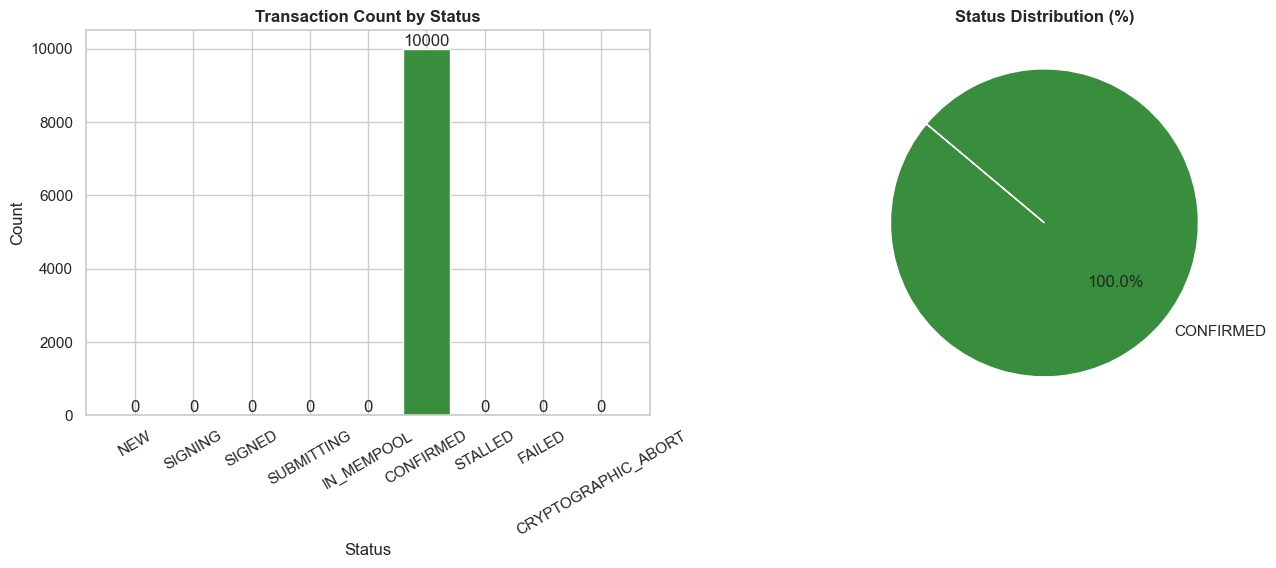

In [6]:
summary = status_summary(df)
display(summary)

colors = [STATUS_COLORS.get(s, "#cccccc") for s in summary.index]
_, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
bars = ax1.bar(summary.index, summary["count"], color=colors)
ax1.bar_label(bars, fmt="%d")
ax1.set_title("Transaction Count by Status", fontweight="bold")
ax1.set_xlabel("Status")
ax1.set_ylabel("Count")
ax1.tick_params(axis="x", rotation=30)

# Pie chart
nonzero = summary[summary["count"] > 0]
pie_colors = [STATUS_COLORS.get(s, "#cccccc") for s in nonzero.index]
ax2.pie(
    nonzero["count"],
    labels=nonzero.index,
    autopct="%1.1f%%",
    colors=pie_colors,
    startangle=140,
)
ax2.set_title("Status Distribution (%)", fontweight="bold")

plt.show()

---
### 6. Recovery Analysis 

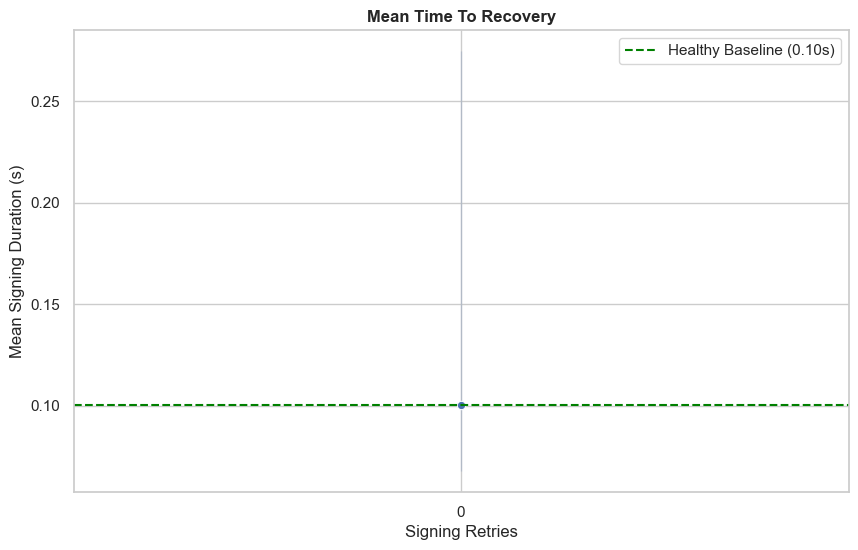

In [7]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df_signed,
    x="signing_retries",
    y="pure_signing_latency_s",
    estimator=np.median,
    errorbar=("pi", 95),
    marker="o",
    linewidth=2,
)

zero_retries = df_signed[df_signed["signing_retries"] == 0]
if not zero_retries.empty:
    baseline_median = zero_retries["pure_signing_latency_s"].median()
    plt.axhline(y=baseline_median, color="green", linestyle="--", label=f"Healthy Baseline ({baseline_median:.2f}s)")
    plt.legend()

max_retries = int(df_signed["signing_retries"].max()) if not df_signed.empty else 0
plt.xticks(range(0, max_retries + 1))

plt.title("Mean Time To Recovery", fontweight="bold")
plt.xlabel("Signing Retries")
plt.ylabel("Mean Signing Duration (s)")
plt.show()

---
### 7. State Consistency Analysis

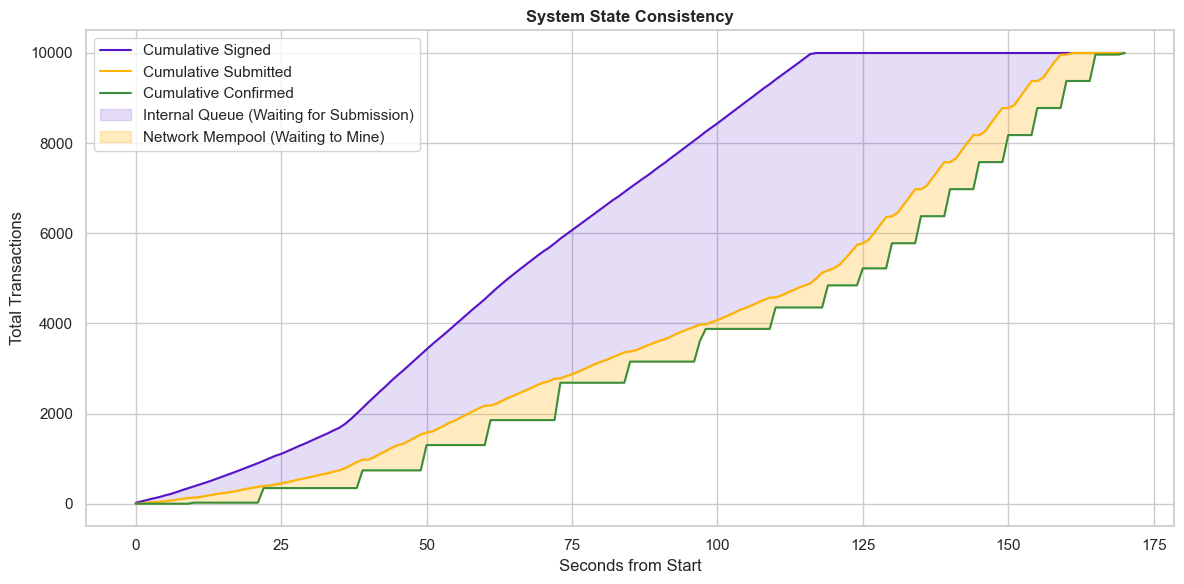

In [8]:
# 1. Normalize timestamps
df["signed_sec"] = pd.to_datetime(df["signed_at"], utc=True).dt.floor("s")
df["submitted_sec"] = pd.to_datetime(df["submitted_at"], utc=True).dt.floor("s")
df["confirmed_sec"] = pd.to_datetime(df["confirmed_at"], utc=True).dt.floor("s")

# 2. Count transactions per second
signed_series = df.groupby("signed_sec")["id"].count()
submitted_series = df.groupby("submitted_sec")["id"].count()
confirmed_series = df.groupby("confirmed_sec")["id"].count()

# 3. Create master timeline
start_time = min(df["signed_sec"].min(), df["submitted_sec"].min(), df["confirmed_sec"].min())
end_time = max(df["signed_sec"].max(), df["submitted_sec"].max(), df["confirmed_sec"].max())
full_timeline = pd.date_range(start=start_time, end=end_time, freq="s")

# 4. Calculate cumulative sums
cumulative_df = pd.DataFrame(index=full_timeline)
cumulative_df["Total Signed"] = signed_series.reindex(full_timeline, fill_value=0).cumsum()
cumulative_df["Total Submitted"] = submitted_series.reindex(full_timeline, fill_value=0).cumsum()
cumulative_df["Total Confirmed"] = confirmed_series.reindex(full_timeline, fill_value=0).cumsum()

# 5. Convert to relative time
cumulative_df["seconds_from_start"] = (cumulative_df.index - start_time).total_seconds()

# 6. Plotting
plt.figure(figsize=(12, 6))

# The three boundary lines
plt.plot(
    cumulative_df["seconds_from_start"],
    cumulative_df["Total Signed"],
    color="#5614c7",
    label="Cumulative Signed",
)
plt.plot(
    cumulative_df["seconds_from_start"],
    cumulative_df["Total Submitted"],
    color="#ffb300",
    label="Cumulative Submitted",
)
plt.plot(
    cumulative_df["seconds_from_start"],
    cumulative_df["Total Confirmed"],
    color="#388e3c",
    label="Cumulative Confirmed",
)

# Fill 1: Internal Java Queue
plt.fill_between(
    cumulative_df["seconds_from_start"],
    cumulative_df["Total Submitted"],
    cumulative_df["Total Signed"],
    color="#5614c7",
    alpha=0.15,
    label="Internal Queue (Waiting for Submission)",
)

# Fill 2: Hardhat Network Mempool
plt.fill_between(
    cumulative_df["seconds_from_start"],
    cumulative_df["Total Confirmed"],
    cumulative_df["Total Submitted"],
    color="#ffb300",
    alpha=0.25,
    label="Network Mempool (Waiting to Mine)",
)

plt.title("System State Consistency", fontweight="bold")
plt.xlabel("Seconds from Start")
plt.ylabel("Total Transactions")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()